# Intro

PCA analysis on the meta-session to see value (history) representation.

---
# Setup

In [1]:
#%% imports
import os

from sklearn.decomposition import PCA
import pandas as pdr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score




import popy.config as cfg
from popy.config import COLORS

#from popy.dim_reduction import *
from popy.plotting.plotting_tools import plot_keypoints
from popy.plotting.plot_cortical_grid import plot_on_cortical_grid

PATH = cfg.PROJECT_PATH_LOCAL

In [2]:
#%% data tools
def load_data_custom():
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_value_4x20')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    # add a coord along the trial_id dim, which is the mean of the switch_info along units. its called switch_proba
    #neural_dataset = neural_dataset.assign_coords(switch_proba = ('trial_id', neural_dataset['switch_info'].mean(dim='unit').data))
    #drop switch_info from
    #neural_dataset = neural_dataset.drop('switch_info')

    #neural_dataset = neural_dataset.assign_coords(time_m1=('time', neural_dataset.time.values + 7.5))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data

    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

def fit_transform_data(neural_dataset):
    n_trials, n_neurons, n_time = neural_dataset.firing_rates.data.shape
        
    # Step 1: Reshape to (neurons, trials*time)
    reshaped_data = neural_dataset.firing_rates.data.transpose(1, 0, 2).reshape(n_neurons, -1)

    # Step 2: Apply PCA (scikit-learn expects samples as rows, features as columns)
    pca = PCA()
    pca = pca.fit(reshaped_data.T)  # Shape: (trials*time, components)
    transformed_data = pca.transform(reshaped_data.T)  # Apply PCA transformation

    # Step 3: Reshape back to (trials, components, time)
    transformed_data = transformed_data.T  # Shape: (components, trials*time)
    transformed_data = transformed_data.reshape(n_neurons, n_trials, n_time)
    transformed_data = transformed_data.transpose(1, 0, 2)  # Final shape: (trials, components, time)

    # rewrite the dataset
    pca_dataset = neural_dataset.copy(deep=True)
    pca_dataset = pca_dataset.rename({'unit': 'pca_component'})
    pca_dataset = pca_dataset.drop('channel')
    pca_dataset = pca_dataset.drop('area')
    pca_dataset = pca_dataset.drop('unit_id_original')
    pca_dataset = pca_dataset.drop('monkey')
    pca_dataset = pca_dataset.drop('session')
    # add pca_component dimension
    pca_dataset = pca_dataset.assign_coords(pca_component=('pca_component', np.arange(n_neurons)))
    pca_dataset = pca_dataset.assign_coords(explained_var=('pca_component', pca.explained_variance_ratio_))
    pca_dataset.firing_rates.data = transformed_data

    # create xr dataset for the pca components (components, units)
    pca_components = xr.DataArray(pca.components_, dims=['pca_component', 'unit'], coords=[np.arange(n_neurons), neural_dataset.unit.values])

    return pca_dataset, pca_components


def get_weights_per_area(pca_components, pca_component):
    '''
    Get the weights of the PCA components per area
    '''
    weights_temp = pca_components.sel(pca_component=pca_component)

    # to df, where columns are monkey, session, area, unit, weight
    data_to_df = []
    for unit_temp in weights_temp.unit.values:
        data_to_df.append(
            {'monkey': unit_temp.split('_')[0],
            'session': unit_temp.split('_')[1],
            'area': unit_temp.split('_')[2],
            'unit': "_".join(unit_temp.split('_')[3:]),
            'weight': weights_temp.sel(unit=unit_temp).values
            }
        )
    df = pdr.DataFrame(data_to_df)
    df['weight_ratio'] =np.abs(df['weight'])/np.sum(np.abs(df['weight']))

    # get best weight per monkey, session, area (drop unit)
    df_abs = df.copy()
    df_abs['weight'] = df_abs['weight'].abs()

    df_best = df_abs.groupby(['monkey', 'session', 'area']).agg({'weight': 'max'}).reset_index()
    df_best = df_best.rename(columns={'weight': 'best_weight'})
    df_best['best_weight_ratio'] = df_best['best_weight'] / df_abs['weight'].sum()

    df_sum = df_abs.groupby(['monkey', 'session', 'area']).agg({'weight': 'sum'}).reset_index()
    df_sum = df_sum.rename(columns={'weight': 'sum_weight'})
    df_sum['sum_weight_ratio'] = df_sum['sum_weight'] / df_abs['weight'].sum()
    df_best = df_best.merge(df_sum, on=['monkey', 'session', 'area'], how='left')

    df_mean = df_abs.groupby(['monkey', 'session', 'area']).agg({'weight': 'mean'}).reset_index()
    df_mean = df_mean.rename(columns={'weight': 'mean_weight'})
    df_best = df_best.merge(df_mean, on=['monkey', 'session', 'area'], how='left')

    return df_best


In [3]:
##% plotting functions

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, permutation_test_score
from sklearn.model_selection import StratifiedKFold

from scipy import stats
import numpy as np

# For a simpler approach, use multiple lines with increasing thickness
def plot_lines(mean_count_a, mean_count_b, mean_count_c, t_min, t_max, label, label_2, ax, thinning=True, colors=None, linestyles=None, i=0, j=0):
        x = mean_count_a.sel(time=slice(t_min, t_max)).data
        y = mean_count_b.sel(time=slice(t_min, t_max)).data
        z = mean_count_c.sel(time=slice(t_min, t_max)).data

        # Number of segments to divide the line into
        num_segments = 10
        segment_size = len(x) // num_segments

        # First plot a slightly thicker grey/black line
        ax.plot(x, y, z, 
                color='black',  # Edge color
                linestyle='-',  # Solid line for the "edge"
                linewidth=5,    # Slightly thicker than your main line
                alpha=1)      # Semi-transparent

        ax.plot(x, y, z, 
                color='white',  # Edge color
                linestyle='-',  # Solid line for the "edge"
                linewidth=4,    # Slightly thicker than your main line
                alpha=1)      # Semi-transparent

        # Then plot your colored dashed line on top
        ax.plot(x, y, z, 
                color=colors[i], 
                linestyle=linestyles[j], 
                linewidth=4,
                label=f'V_t={label} - R_t={label_2}')

def plot_3d_pca_trajectory(pca_dataset, pc1, pc2, pc3):

    # fontsize 18pt in matplotlib settings
    plt.rcParams.update({'font.size': 18})

    t_min, t_max = 2, 11#0, 11

    # Get data
    unit_data_a = pca_dataset.firing_rates.sel(pca_component=pc1)
    #unit_data_a.data = unit_data_a.data - np.mean(unit_data_a.data, axis=0, keepdims=True)
    unit_data_b = pca_dataset.firing_rates.sel(pca_component=pc2)
    #unit_data_b.data = unit_data_b.data - np.mean(unit_data_b.data, axis=0, keepdims=True)
    unit_data_c = pca_dataset.firing_rates.sel(pca_component=pc3)
    unit_data_c.data = unit_data_c.data - np.mean(unit_data_c.data, axis=0, keepdims=True)

    # Create 3D figure
    #elevation, azimuth, roll = -22, -74, 180
    h, w = 6, 6    # in inches
    fig = plt.figure(figsize=(w, h))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=-17, azim=-69, roll=179)  # Set the view angle
    #fig.suptitle(f'PCA components trajectories\n{monkey}, {area}', fontsize=16)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    #ax.grid(axis='x')

    # make the plot longer along the x axis
    #ax.set_box_aspect([3, 1, 1])  # aspect ratio is 1:1:1
    #ax.set_xticks(np.arange(-3, 4, 1))
    #ax.set_yticks(np.arange(-3, 4, 1))


    time_vector = pca_dataset.time.values

    labels = pca_dataset.value_function.values
    labels_2 = pca_dataset.feedback.values
    colors = sns.color_palette("RdYlGn", len(np.unique(labels)))
    linestyles = {0:'--', 1:'-'}


    # Plot the trajectories for each condition
    for i, label in enumerate(np.unique(labels)):
        if label in [1, 2]:
            continue
        if label == 2: i+=1
        # Get trials for this condition
        if labels_2 is not None:
            for j, label_2 in enumerate(np.unique(labels_2)):
                    trial_ids = unit_data_a.trial_id[(labels == label) & (labels_2 == label_2)]
                    mean_count_a = unit_data_a.sel(trial_id=trial_ids).mean(dim='trial_id')
                    mean_count_b = unit_data_b.sel(trial_id=trial_ids).mean(dim='trial_id')
                    mean_count_c = unit_data_c.sel(trial_id=trial_ids).mean(dim='trial_id')

                    # smooth in time
                    mean_count_a.data = np.convolve(mean_count_a.values, np.ones(100)/100, mode='same')
                    mean_count_b.data = np.convolve(mean_count_b.values, np.ones(100)/100, mode='same')
                    mean_count_c.data = np.convolve(mean_count_c.values, np.ones(100)/100, mode='same')

                    # Plot the trajectory
                    plot_lines(mean_count_a, mean_count_b, mean_count_c, t_min, t_max, label, label_2, ax, thinning=True, colors=colors, linestyles=linestyles, i=i, j=j)

                    # scatter times: LV_t: t=2, Fb_t: t=3.5, LV_t+1: t=9.5, Fb_t+1: t=11
                    ax.scatter(mean_count_a.sel(time=2.5).data, mean_count_b.sel(time=2.5).data, mean_count_c.sel(time=2.5).data, color='k', s=30, alpha=0.8, marker='x')
                    ax.scatter(mean_count_a.sel(time=3.5).data, mean_count_b.sel(time=3.5).data, mean_count_c.sel(time=3.5).data, color='k', s=30, alpha=0.8, marker='o')
                    ax.scatter(mean_count_a.sel(time=10).data, mean_count_b.sel(time=10).data, mean_count_c.sel(time=10).data, color='k', s=30, alpha=0.8, marker='X')
                    #ax.scatter(mean_count_a.sel(time=9.5).data, mean_count_b.sel(time=9.5).data, mean_count_c.sel(time=9.5).data, label='Lv(t+1)', color='k', s=30, alpha=0.8, marker='^')
                    ax.scatter(mean_count_a.sel(time=11).data, mean_count_b.sel(time=11).data, mean_count_c.sel(time=11).data, color='k', s=30, alpha=0.8, marker='s')
        else:
            trial_ids = unit_data_a.trial_id[labels == label]
            mean_count_a = np.mean(unit_data_a.sel(trial_id=trial_ids), axis=0)
            mean_count_b = np.mean(unit_data_b.sel(trial_id=trial_ids), axis=0)
            mean_count_c = np.mean(unit_data_c.sel(trial_id=trial_ids), axis=0)

            # Plot the trajectory
            ax.plot(mean_count_a.values, mean_count_b.values, mean_count_c.values, label=f'V_t={label}', color=colors[i])
        
        # Add markers to show direction of time
        '''ax.scatter(time_vector, mean_a.values, mean_b.values, 
                color=colors[i], s=30, alpha=0.8)'''

    # Set labels
    '''ax.set_xlabel(f'PCA component {unit_data_a.pca_component.data}, variance explained: {unit_data_a.explained_var*100:.1f}%')
    ax.set_ylabel(f'PCA component {unit_data_b.pca_component.data}, variance explained: {unit_data_b.explained_var*100:.1f}%')
    ax.set_zlabel(f'PCA component {unit_data_c.pca_component.data}, variance explained: {unit_data_c.explained_var*100:.1f}%')'''
    ax.set_xlabel(f'PC {unit_data_a.pca_component.data}')
    ax.set_ylabel(f'PC {unit_data_b.pca_component.data}')
    ax.set_zlabel(f'PC {unit_data_c.pca_component.data}')

    # hide ticklabels
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])


    # reorder legend labels: put every second on the second column
    handles, labels = ax.get_legend_handles_labels()
    handles_pos = [handles[i] for i in range(len(labels)) if i % 2 == 1]
    handles_neg = [handles[i] for i in range(len(labels)) if i % 2 == 0]
    handles = handles_pos + handles_neg
    labels_pos = [labels[i] for i in range(len(labels)) if i % 2 == 1]
    labels_neg = [labels[i] for i in range(len(labels)) if i % 2 == 0]
    labels = labels_pos + labels_neg

    # Add legend
    ax.scatter([], [], [], color='k', s=30, alpha=0.8, marker='x', label='Tt(t)')
    ax.scatter([], [], [], color='k', s=30, alpha=0.8, marker='X', label='Tt(t+1)')
    ax.scatter([], [], [], color='k', s=30, alpha=0.8, marker='o', label='Fb(t)')
    ax.scatter([], [], [], color='k', s=30, alpha=0.8, marker='s', label='Fb(t+1)')

    # Reorder legend labels: add scattered markers last
    handles, labels = ax.get_legend_handles_labels()
    scattered_handles = handles[-3:]  # Last three are the scattered markers
    scattered_labels = labels[-3:]
    other_handles = handles[:-3]
    other_labels = labels[:-3]

    handles = other_handles + scattered_handles
    labels = other_labels + scattered_labels

    ax.legend(handles, labels, loc='upper left', fontsize=8, ncol=1)

    ax.legend(handles, labels, loc='upper left', fontsize=8, ncol=1)
    #ax.legend(title='history of feedback', loc='upper right')

    #plot_keypoints(ax, n_extra_trials=(0, 1))

    #ax.set_xlim(2, 11)
    ax.grid(None)
    # Export 3d plot in interactive mode
    # save to html

    #plt.title(f'KA - MCC, PC{unit_data_a.pca_component.data} vs PC{unit_data_b.pca_component.data} vs PC{unit_data_c.pca_component.data}')

    return fig, ax


def plot_2d_pca_trajectory(pca_dataset, pc1=3, pc2=5):    
    # Get data
    unit_data_a = pca_dataset.firing_rates.sel(pca_component=pc1)
    unit_data_a.data = unit_data_a.data - np.mean(unit_data_a.data, axis=0, keepdims=True)
    unit_data_b = pca_dataset.firing_rates.sel(pca_component=pc2)
    #unit_data_b.data = unit_data_b.data - np.mean(unit_data_b.data, axis=0, keepdims=True)

    # Create 3D figure
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    #fig.suptitle(f'PCA components trajectories\n{monkey}, {area}', fontsize=16)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(axis='x')

    # make the plot longer along the x axis
    ax.set_box_aspect([3, 1, 1])  # aspect ratio is 1:1:1
    #ax.set_xticks(np.arange(-3, 4, 1))
    #ax.set_yticks(np.arange(-3, 4, 1))

    time_vector = pca_dataset.time.values

    labels = pca_dataset.value_function.values
    labels_2 = pca_dataset.feedback.values
    colors = sns.color_palette("RdYlGn", len(np.unique(labels)))
    linestyles = {0:'dotted', 1:'-'}

    # Plot the trajectories for each condition
    for i, label in enumerate(np.unique(labels)):
        if label in [1, 2]:
            continue
        if label == 2: i+=1
        # Get trials for this condition
        if labels_2 is not None:
            for j, label_2 in enumerate(np.unique(labels_2)):
                    trial_ids = unit_data_a.trial_id[(labels == label) & (labels_2 == label_2)]
                    mean_count_a = np.mean(unit_data_a.sel(trial_id=trial_ids), axis=0)
                    mean_count_b = np.mean(unit_data_b.sel(trial_id=trial_ids), axis=0)

                    # smooth in time
                    mean_count_a_smooth_data = np.convolve(mean_count_a.values, np.ones(50)/50, mode='same')
                    mean_count_b_smooth_data = np.convolve(mean_count_b.values, np.ones(50)/50, mode='same')

                    # Plot the trajectory
                    ax.plot(time_vector, mean_count_a_smooth_data, mean_count_b_smooth_data, label=f'V_t={label} - R_t={label_2}', color=colors[i], linestyle=linestyles[j])
        else:
            trial_ids = unit_data_a.trial_id[labels == label]
            mean_count_a = np.mean(unit_data_a.sel(trial_id=trial_ids), axis=0)
            mean_count_b = np.mean(unit_data_b.sel(trial_id=trial_ids), axis=0)

            # Plot the trajectory
            ax.plot(time_vector, mean_count_a.values, mean_count_b.values, label=f'V_t={label}', color=colors[i])
        
        # Add markers to show direction of time
        '''ax.scatter(time_vector, mean_a.values, mean_b.values, 
                color=colors[i], s=30, alpha=0.8)'''

    # Set labels
    ax.set_ylabel(f'PCA component {unit_data_a.pca_component.data}, variance explained: {unit_data_a.explained_var*100:.1f}%')
    ax.set_zlabel(f'PCA component {unit_data_b.pca_component.data}, variance explained: {unit_data_b.explained_var*100:.1f}%')
    ax.set_xlabel('Time (s)')

    # Add legend
    # reorder legend labels: put every second on the second column
    handles, labels = ax.get_legend_handles_labels()
    handles_pos = [handles[i] for i in range(len(labels)) if i % 2 == 1]
    handles_neg = [handles[i] for i in range(len(labels)) if i % 2 == 0]
    handles = handles_pos + handles_neg
    labels_pos = [labels[i] for i in range(len(labels)) if i % 2 == 1]
    labels_neg = [labels[i] for i in range(len(labels)) if i % 2 == 0]
    labels = labels_pos + labels_neg
    ax.legend(handles, labels, loc='upper left', fontsize=8, ncol=2)
    #ax.legend(title='history of feedback', loc='upper right')

    plot_keypoints(ax, n_extra_trials=(0, 1))

    ax.set_xlim(2, 11)

    # Export 3d plot in interactive mode
    # save to html

    #plt.tight_layout()

    plt.show()
    #plt.close()

def calculate_r_squared(firing_rates, neural_values):
    # zscore the neural values
    neural_values = (neural_values - np.mean(neural_values)) / np.std(neural_values)

    # One-way ANOVA
    groups = [firing_rates[neural_values == level] for level in np.unique(neural_values)]
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Calculate R-squared
    ss_between = sum(len(group) * (np.mean(group) - np.mean(firing_rates))**2 
                     for group in groups)
    ss_total = sum((firing_rates - np.mean(firing_rates))**2)
    r_squared = ss_between / ss_total
    
    return r_squared, p_value

def calculate_anova(dV, fbs):
    # Put into a DataFrame
    df = pd.DataFrame({"dV": dV, "fb": fbs})

    # Fit one-way ANOVA via OLS
    model = smf.ols("dV ~ C(fb)", data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    # Compute eta squared (variance explained)
    ss_between = anova_table["sum_sq"]["C(fb)"]
    ss_total = anova_table["sum_sq"].sum()
    eta_squared = ss_between / ss_total

    # Extract p-value
    p_value = anova_table.loc["C(fb)", "PR(>F)"]

    return eta_squared, p_value
    
    '''
    # Split into groups
    dV0 = dV[fbs == 0]
    dV1 = dV[fbs == 1]

    # Group sizes
    n0, n1 = len(dV0), len(dV1)

    # Group means
    m0, m1 = dV0.mean(), dV1.mean()

    # Overall mean
    m = dV.mean()

    # --- ANOVA decomposition ---
    # Between-group sum of squares
    SS_between = n0 * (m0 - m)**2 + n1 * (m1 - m)**2

    # Within-group sum of squares
    SS_within = ((dV0 - m0)**2).sum() + ((dV1 - m1)**2).sum()

    # Total sum of squares
    SS_total = ((dV - m)**2).sum()

    # Variance explained (eta squared)
    eta_sq = SS_between / SS_total

    return eta_sq'''


def calculate_mixed_effect(value, feedback, V_t, dV):
    # Assume your DataFrame has columns: V_t, dV, value, feedback
    # df = pd.DataFrame(...)
    df = pd.DataFrame({"dV": dV, "fb": feedback, "V_t": V_t, "value": value})

    # 1) How much 'value' explains 'V_t' using ANOVA (value has 4 classes)
    model_val = smf.ols("V_t ~ C(value)", data=df).fit()
    anova_val = sm.stats.anova_lm(model_val, typ=2)
    ss_between_val = anova_val.loc["C(value)", "sum_sq"]
    ss_total_val = anova_val["sum_sq"].sum()
    eta_sq_value = ss_between_val / ss_total_val
    pval_value = anova_val.loc["C(value)", "PR(>F)"]

    # 2) How much 'feedback' explains 'dV' using ANOVA
    model_fb = smf.ols("dV ~ C(feedback)", data=df).fit()
    anova_fb = sm.stats.anova_lm(model_fb, typ=2)
    ss_between_fb = anova_fb.loc["C(feedback)", "sum_sq"]
    ss_total_fb = anova_fb["sum_sq"].sum()
    eta_sq_fb = ss_between_fb / ss_total_fb
    pval_fb = anova_fb.loc["C(feedback)", "PR(>F)"]

    return (eta_sq_value, pval_value), (eta_sq_fb, pval_fb)


def print_best_pcs(r_squared, p_vals):
    # Find significant indices (typically p < 0.05)
    alpha = 0.05
    significant_mask = p_vals < alpha
    significant_indices = np.where(significant_mask)[0]

    if len(significant_indices) == 0:
        print("No significant neurons found")
    else:
        # Get R-squared values for significant neurons only
        sig_r_squared = r_squared[significant_indices]
        sig_p_vals = p_vals[significant_indices]
        
        # Sort by R-squared in descending order
        sort_order = np.argsort(sig_r_squared)[::-1]
        
        # Get top 10 (or fewer if less than 10 significant)
        top_n = min(10, len(sort_order))
        top_indices = significant_indices[sort_order[:top_n]]
        top_r_squared = sig_r_squared[sort_order[:top_n]]
        top_p_vals = sig_p_vals[sort_order[:top_n]]
        
        print("Top 10 significant neurons (sorted by R-squared):")
        print("Rank | Neuron Index | R-squared | p-value")
        print("-" * 45)
        for i in range(top_n):
            print(f"{i+1:4d} | {top_indices[i]:11d} | {top_r_squared[i]:8.4f} | {top_p_vals[i]:7.2e}")

def _plot_explained_variance(pca_dataset_all):
    
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

    for ax_i, (area, pca_dataset) in enumerate(pca_dataset_all.items()):

        n_components = np.min((100, len(pca_dataset.pca_component.values)))
        
        r2s = []
        pvals = []
        for i in range(n_components):  # loop through PCs and calculate variance
            # prepare data for this PC
            neural_values = pca_dataset.firing_rates.sel(pca_component=i, time=slice(0, 3.5)).mean('time').data  # select PC, get one mean value per trial
            behavioral_values = pca_dataset.value_function.values  # get behavioral values

            # zscore the neural values
            neural_values = (neural_values - np.mean(neural_values)) / np.std(neural_values)

            r_squared, pvalue = calculate_r_squared(neural_values, behavioral_values)

            # calculate variance explained by this PC using linear regression
            #skf = StratifiedKFold(n_splits=10, shuffle=True)  # stratified K-fold cross-validation
            #model = LinearRegression()
            # get cross-validated R²
            #r_squared = cross_val_score(model, neural_values.reshape(-1, 1), behavioral_values, cv=skf).mean()
            #r_squared, permutation_scores, pvalue = permutation_test_score(
            #    model, neural_values.reshape(-1, 1), behavioral_values, random_state=0, n_jobs=11, n_permutations=100, cv=skf
            #)
            #pvalue = 1  # placeholder, as we are not using permutation test here


            r2s.append(r_squared)
            pvals.append(pvalue)

        pvals = np.array(pvals)
        r2s = np.array(r2s)

        # print best units
        print("Best PCs for area:", area)
        print_best_pcs(r2s, pvals)

        ax = axs[ax_i]

        # ids of pcs that are significantly higher than the mean
        ax.plot(np.arange(n_components), r2s)

        is_significant = np.where(pvals < 0.05)[0]  # significant PCs

        ax.scatter(np.arange(n_components)[is_significant], r2s[is_significant], color='r', label='significant')

        ax.axhline(0, color='k', linestyle='--')

        ax.set_xlabel('PCA component')
        ax.set_ylabel('Value-related variance explained')
        ax.set_title(f'{area}')
        #ax.grid(alpha=.3, axis='x')
        sns.despine()

        ax.set_xlim([-1, 100])
        ax.axvline(15, color='k', linestyle='-', alpha=.5, label='first15 PCs')

        ax.legend(loc='upper right', fontsize=8)

    return fig, axs

def plot_explained_variance(pca_dataset_all, n_comps=10000):
    
    fig, axs = plt.subplots(3, 3, figsize=(12, 12), sharex='row', sharey='row')

    for ax_i, (area, pca_dataset) in enumerate(pca_dataset_all.items()):

        n_components = np.min((n_comps, len(pca_dataset.pca_component.values)))

        r2s_value, r2s_feedback = [], []
        pvals_value, pvals_feedback = [], []
        for i in range(n_components):  # loop through PCs and calculate variance
            # prepare data for this PC
            V_t = pca_dataset.firing_rates.sel(pca_component=i, time=slice(1, 3.5)).mean('time').data  # select PC, get one mean value per trial
            V_tp1 = pca_dataset.firing_rates.sel(pca_component=i, time=slice(8.5, 11)).mean('time').data  # select PC, get one mean value per trial
            dV = V_tp1 - V_t  # difference between timepoints

            behavioral_values = pca_dataset.value_function.values  # get behavioral values
            fbs = pca_dataset.feedback.values  # get feedback values

            # old way: just V_t agains behavioral values
            '''r_squared_value, pvalue_value = calculate_r_squared(V_t, behavioral_values)

            # new way: dV (continuous) against fbs (0, 1)
            r_squared_feedback, p_value_feedback = calculate_anova(dV, fbs)'''

            # new way 2: mixed effect model
            (r_squared_value, pvalue_value), (r_squared_feedback, p_value_feedback) = calculate_mixed_effect(behavioral_values, fbs, V_t, dV)

            r2s_value.append(r_squared_value)
            r2s_feedback.append(r_squared_feedback)
            pvals_value.append(pvalue_value)
            pvals_feedback.append(p_value_feedback)
        r2s_value = np.array(r2s_value)
        pvals_value = np.array(pvals_value)
        r2s_feedback = np.array(r2s_feedback)
        pvals_feedback = np.array(pvals_feedback)

        # print stats: ranked list of best pcs: normalize both r2s and get the best multiplicative effect
        print("Best PCs for area:", area)
        r2s_feedback_norm = (r2s_feedback - np.min(r2s_feedback)) / (np.max(r2s_feedback) - np.min(r2s_feedback))
        r2s_value_norm = (r2s_value - np.min(r2s_value)) / (np.max(r2s_value) - np.min(r2s_value))
        mixed_effect = r2s_feedback_norm * r2s_value_norm
        print("Best PCs for area (mixed effect):")
        print_best_pcs(mixed_effect, np.minimum(pvals_value, pvals_feedback))

        # Individual variance plot (top row)
        ax_individual = axs[0, ax_i]
        ax_individual.plot(np.arange(n_components), r2s_value)

        is_significant = np.where(pvals_value < 0.05)[0]  # significant PCs
        ax_individual.scatter(np.arange(n_components)[is_significant], r2s_value[is_significant], color='r', label='significant')

        ax_individual.axhline(0, color='k', linestyle='--')
        ax_individual.set_ylabel('neural value variance explained by behavioral value')
        ax_individual.set_title(f'{area} - Value vs neural value')
        ax_individual.set_xlim([-1, 100])
        ax_individual.axvline(15, color='k', linestyle='-', alpha=.5, label='first15 PCs')
        ax_individual.legend(loc='upper right', fontsize=8)

        # Individual variance plot (top row)
        ax_individual = axs[1, ax_i]
        ax_individual.plot(np.arange(n_components), r2s_feedback)

        is_significant = np.where(pvals_feedback < 0.05)[0]  # significant PCs
        ax_individual.scatter(np.arange(n_components)[is_significant], r2s_feedback[is_significant], color='r', label='significant')

        ax_individual.axhline(0, color='k', linestyle='--')
        ax_individual.set_ylabel('dV variance explained by feedback')
        ax_individual.set_title(f'{area} - Feedback vs dV')
        ax_individual.set_xlim([-1, 100])
        ax_individual.axvline(15, color='k', linestyle='-', alpha=.5, label='first15 PCs')
        ax_individual.legend(loc='upper right', fontsize=8)
        
        # Individual variance plot (top row)
        ax_individual = axs[2, ax_i]

        #  scatter plot of r2s_1 against r2s_2, print little numbers of the pc component next to the points
        for i, (r2_1, pval_1, r2_2, pval_2) in enumerate(zip(r2s_value, pvals_value, r2s_feedback, pvals_feedback)):
            if pval_1 < 0.05 and pval_2 < 0.05:
                ax_individual.scatter(r2_1, r2_2, color='tab:purple')
                ax_individual.text(r2_1, r2_2, f'{i}', fontsize=8)
            elif pval_1 < 0.05:
                ax_individual.scatter(r2_1, r2_2, color='tab:blue')
                ax_individual.text(r2_1, r2_2, f'{i}', fontsize=8)
            elif pval_2 < 0.05:
                ax_individual.scatter(r2_1, r2_2, color='tab:green')
                ax_individual.text(r2_1, r2_2, f'{i}', fontsize=8)
            else:
                ax_individual.scatter(r2_1, r2_2, color='tab:grey', alpha=0.5)

        ax_individual.set_xlabel('neural value explained by behavioral value')
        ax_individual.set_ylabel('dV explained by feedback')
        ax_individual.set_title(f'{area} - "Mixed effect"')
        '''ax_individual.set_xlim([-0.01, 0.2])
        ax_individual.set_ylim([-0.01, 0.2])'''
        ax_individual.axvline(0, color='k', linestyle='--')
        ax_individual.axhline(0, color='k', linestyle='--')
        #ax_individual.axvline(0.05, color='blue', linestyle='--', alpha=0.5, label='p<0.05 for V_t')
        #ax_individual.axhline(0.05, color='green', linestyle='--', alpha=0.5, label='p<0.05 for dV')
        # add legend: colors for coding types
        # add legend: colors for coding types
        legends = {'none': 'tab:grey', 
                'value only': 'tab:blue', 
                'feedback only': 'tab:green', 
                'both': 'tab:purple'}

        # Create legend handles
        legend_handles = []
        for label, color in legends.items():
            if label == 'none':
                handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                                markersize=6, alpha=0.5, label=f'{label} (p≥0.05)')
            else:
                handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                                markersize=6, label=f'{label} (p<0.05)')
            legend_handles.append(handle)

        ax_individual.legend(handles=legend_handles, loc='upper left', fontsize=8)

        #ax_individual.legend(loc='upper right', fontsize=8)
        
        sns.despine()

    plt.tight_layout()
    return fig, axs

def plot_mixed_explained_variance(pca_dataset_all, n_comps=10000):
        
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex='row', sharey='row')

    for ax_i, (area, pca_dataset) in enumerate(pca_dataset_all.items()):

        n_components = np.min((n_comps, len(pca_dataset.pca_component.values)))

        r2s_value, r2s_feedback = [], []
        pvals_value, pvals_feedback = [], []
        for i in range(n_components):  # loop through PCs and calculate variance
            # prepare data for this PC
            V_t = pca_dataset.firing_rates.sel(pca_component=i, time=slice(1, 3.5)).mean('time').data  # select PC, get one mean value per trial
            V_tp1 = pca_dataset.firing_rates.sel(pca_component=i, time=slice(8.5, 11)).mean('time').data  # select PC, get one mean value per trial
            dV = V_tp1 - V_t  # difference between timepoints

            behavioral_values = pca_dataset.value_function.values  # get behavioral values
            fbs = pca_dataset.feedback.values  # get feedback values

            # old way: just V_t agains behavioral values
            '''r_squared_value, pvalue_value = calculate_r_squared(V_t, behavioral_values)

            # new way: dV (continuous) against fbs (0, 1)
            r_squared_feedback, p_value_feedback = calculate_anova(dV, fbs)'''

            # new way 2: mixed effect model
            (r_squared_value, pvalue_value), (r_squared_feedback, p_value_feedback) = calculate_mixed_effect(behavioral_values, fbs, V_t, dV)

            r2s_value.append(r_squared_value)
            r2s_feedback.append(r_squared_feedback)
            pvals_value.append(pvalue_value)
            pvals_feedback.append(p_value_feedback)
        r2s_value = np.array(r2s_value)
        pvals_value = np.array(pvals_value)
        r2s_feedback = np.array(r2s_feedback)
        pvals_feedback = np.array(pvals_feedback)

        # print stats: ranked list of best pcs: normalize both r2s and get the best multiplicative effect
        print("Best PCs for area:", area)
        r2s_feedback_norm = (r2s_feedback - np.min(r2s_feedback)) / (np.max(r2s_feedback) - np.min(r2s_feedback))
        r2s_value_norm = (r2s_value - np.min(r2s_value)) / (np.max(r2s_value) - np.min(r2s_value))
        mixed_effect = r2s_feedback_norm * r2s_value_norm

        # Individual variance plot (top row)
        ax_individual = axs[ax_i]
        ax_individual.plot(np.arange(n_components), mixed_effect)

        ax_individual.axhline(0, color='k', linestyle='--')
        ax_individual.set_ylabel('neural value variance explained by behavioral value')
        ax_individual.set_title(f'{area} - Value vs neural value')
        ax_individual.set_xlim([-1, 100])
        ax_individual.axvline(15, color='k', linestyle='-', alpha=.5, label='first15 PCs')
        ax_individual.legend(loc='upper right', fontsize=8)

        sns.despine()

    plt.tight_layout()
    return fig, axs


def plot_pca_trajectory(pca_dataset, monkey, pca_comp, paper_format=False):
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        lw = 2
        h, w = 1.5 *.8 , 3 *.7
    else:   
        plt.rcParams.update({'font.size': 18})
        lw = 3
        h, w = 4, 6

    # Get data
    unit_data_a = pca_dataset.firing_rates.sel(pca_component=pca_comp)

    # if high values are lower, flip the data
    if unit_data_a.sel(trial_id=unit_data_a.value_function == 2).mean().data < unit_data_a.sel(trial_id=unit_data_a.value_function == 0).mean().data:
        unit_data_a.data = -unit_data_a.data

    # substract mean 
    unit_data_a.data = unit_data_a.data - np.mean(unit_data_a.data, axis=0, keepdims=True)

    # Create 3D figure
    fig, ax = plt.subplots(1, 1, figsize=(w, h))

    time_vector = pca_dataset.time.values

    labels = pca_dataset.value_function.values
    labels_2 = pca_dataset.feedback.values
    colors = [COLORS[0], 'grey', COLORS[1]]
    linestyles = {0:'--', 1:'-'}

    # merge labels 1 and 2 into one label (1 for both)
    mapping = {0:0, 1: 1, 2: 2, 3: 2}  # merge labels 1 and 2 into one label (1 for both)
    labels = np.array([mapping[x] for x in labels])

    # Plot the trajectories for each condition
    colors_count = 0
    for i, label in enumerate(np.unique(labels)):
        # Get trials for this condition
        if labels_2 is not None:
            for j, label_2 in enumerate(np.unique(labels_2)):
                    trial_ids = unit_data_a.trial_id[(labels == label) & (labels_2 == label_2)]
                    mean_count_a = np.mean(unit_data_a.sel(trial_id=trial_ids), axis=0)

                    # smooth in time
                    mean_count_a_smooth_data = np.convolve(mean_count_a.values, np.ones(50)/50, mode='same')

                    # Plot the trajectory
                    ax.plot(time_vector, mean_count_a_smooth_data, label=f'V_t={label} - R_t={label_2}', color=colors[colors_count], linestyle=linestyles[j], alpha=0.8)
            colors_count += 1
        else:
            trial_ids = unit_data_a.trial_id[labels == label]
            mean_count_a = np.mean(unit_data_a.sel(trial_id=trial_ids), axis=0)

            # Plot the trajectory
            ax.plot(time_vector, mean_count_a.values, label=f'V_t={label}', color=colors[i])
        
        # Add markers to show direction of time
        '''ax.scatter(time_vector, mean_a.values, mean_b.values, 
                color=colors[i], s=30, alpha=0.8)'''

    # Set labels
    ax.set_ylabel(f'PC {unit_data_a.pca_component.data}')
    ax.set_xlabel('Time (s)')

    # Add legend
    # reorder legend labels: put every second on the second column
    handles, labels = ax.get_legend_handles_labels()
    handles_pos = [handles[i] for i in range(len(labels)) if i % 2 == 1]
    handles_neg = [handles[i] for i in range(len(labels)) if i % 2 == 0]
    handles = handles_pos + handles_neg
    labels_pos = [labels[i] for i in range(len(labels)) if i % 2 == 1]
    labels_neg = [labels[i] for i in range(len(labels)) if i % 2 == 0]
    labels = labels_pos + labels_neg
    ax.legend(handles, labels, loc='upper right', fontsize=8, ncol=1)
    #ax.legend(title='history of feedback', loc='upper right')

    plot_keypoints(ax, n_extra_trials=(0, 1), xlabels='events', mark_event='Fb')
    ax.set_xlim([1, 11.1])

    #plt.tight_layout()
    ax.grid(axis='x', alpha=.3)
    sns.despine()

    return fig, ax


def plot_pca_components_history(pca_dataset, pca_components, monkey, area_title, n_components=10, t_min=None, t_max=None, mean_subtract=False):
    # define what to show
    value_labels = pca_dataset.fb_sequence_m1.values
    outcome_labels = pca_dataset.R_1.values

    # shift time! it is necessary if the value now belongs to the previous trial

    fig, axs = plt.subplots(n_components, 2, figsize=(16, 4*n_components), sharex=False)
    fig.suptitle(f'{monkey}, {area_title}', y=1)

    colors = sns.color_palette("RdYlGn", len(np.unique(value_labels)))  # colors for each value
    linestyles = {0:'--', 1:'-'}  # linestyles for each feedback

    for i in range(n_components):
        # prepare data for this PC
        unit_data = pca_dataset.firing_rates.sel(pca_component=i)  # select PC
        unit_data.data = np.array([np.convolve(trial, np.ones(50)/50, mode='same') for trial in unit_data.data])  # smooth the data

        if t_min is not None and t_max is not None:  # select time window
            unit_data = unit_data.sel(time=slice(t_min, t_max))  

        if mean_subtract:  # substract mean along time
            unit_data.data = unit_data.data - np.mean(unit_data.data, axis=0, keepdims=True)  

        # plot single PC activity
        ax = axs[i, 0]
        plot_single_unit(unit_data, value_labels, labels_2=outcome_labels,
                        title=f'PCA component {i}, variance explained: {pca_dataset.explained_var[i]*100:.1f}%',
                        n_extra_trials=(0, 1),
                        ax=ax, colors=colors, linestyles=linestyles)
        ax.set_ylabel('activity')  # rewrite y label from firing rate to activity"""

        # plot weights on the surface
        """
        What should be the measure? The proble is the weights are correspondig to units, and we want to plot weights over areas, thus we need to average the weights over units somehow.
        Solution 1: average the weights over units per area
        Solution 2: Plot best unit per area
        Solution 3: plot proportion of weights per area relative to all units (e.g. 0.5 means that 50% of the weights are in this area)
        """
        ax = axs[i, 1]
        
        df_weights = get_weights_per_area(pca_components, i)
        df_weights['sum_weight_ratio'] = df_weights['sum_weight_ratio'] * 100  # convert to percentage

        plot_on_cortical_grid(df_weights, 'sum_weight_ratio', 
                            ax=ax, 
                            title=f'PCA component {i}, variance explained: {pca_dataset.explained_var[i]*100:.1f}%',
                            bar_title='percentage of weights given by area (%)',) 

    plt.tight_layout()


def plot_pca_components_value(pca_dataset, pca_components, monkey, area_title, n_components=10, t_min=None, t_max=None, mean_subtract=False):
    # define what to show
    value_labels = pca_dataset.value_function.values
    outcome_labels = pca_dataset.feedback.values

    # shift time! it is necessary if the value now belongs to the previous trial

    fig, axs = plt.subplots(n_components, 2, figsize=(16, 4*n_components), sharex=False)
    fig.suptitle(f'{monkey}, {area_title}', y=1)

    colors = sns.color_palette("RdYlGn", len(np.unique(value_labels)))  # colors for each value
    linestyles = {0:'--', 1:'-'}  # linestyles for each feedback

    for i in range(n_components):
        # prepare data for this PC
        unit_data = pca_dataset.firing_rates.sel(pca_component=i)  # select PC
        unit_data.data = np.array([np.convolve(trial, np.ones(50)/50, mode='same') for trial in unit_data.data])  # smooth the data

        if t_min is not None and t_max is not None:  # select time window
            unit_data = unit_data.sel(time=slice(t_min, t_max))  

        if mean_subtract:  # substract mean along time
            unit_data.data = unit_data.data - np.mean(unit_data.data, axis=0, keepdims=True)  

        # plot single PC activity
        ax = axs[i, 0]
        plot_single_unit(unit_data, value_labels, labels_2=outcome_labels,
                        title=f'PCA component {i}, variance explained: {pca_dataset.explained_var[i]*100:.1f}%',
                        n_extra_trials=(0, 1),
                        ax=ax, colors=colors, linestyles=linestyles)
        ax.set_ylabel('activity')  # rewrite y label from firing rate to activity"""

        # plot weights on the surface
        """
        What should be the measure? The proble is the weights are correspondig to units, and we want to plot weights over areas, thus we need to average the weights over units somehow.
        Solution 1: average the weights over units per area
        Solution 2: Plot best unit per area
        Solution 3: plot proportion of weights per area relative to all units (e.g. 0.5 means that 50% of the weights are in this area)
        """
        ax = axs[i, 1]
        
        df_weights = get_weights_per_area(pca_components, i)
        df_weights['sum_weight_ratio'] = df_weights['sum_weight_ratio'] * 100  # convert to percentage

        plot_on_cortical_grid(df_weights, 'sum_weight_ratio', 
                            ax=ax, 
                            title=f'PCA component {i}, variance explained: {pca_dataset.explained_var[i]*100:.1f}%',
                            bar_title='percentage of weights given by area (%)',) 

    plt.tight_layout()

    return fig, axs



def plot_correlation_matrix(neural_dataset, monkey, area_title):
    reshaped_data = neural_dataset.firing_rates.data.transpose(1, 0, 2).reshape(len(neural_dataset.unit), -1)
    corr_matrix = np.corrcoef(reshaped_data)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-.1, vmax=.1)
    plt.title(f'Correlation Matrix of all Firing Rates\n{monkey} {area_title}')
    plt.xlabel('Units')
    plt.ylabel('Units')
    plt.show()

    
def plot_single_unit(unit_data, labels, labels_2=None, colors=None, linestyles=None, n_extra_trials=(-1, 0), title=None, ax=None):
    time_vector = unit_data.time.data

    # plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    # get mean counts by conditions
    for i, label in enumerate(np.unique(labels)):
        if labels_2 is not None:
            for j, label_2 in enumerate(np.unique(labels_2)):
                trial_ids = unit_data.trial_id[(labels == label) & (labels_2 == label_2)]
                mean_count = np.mean(unit_data.sel(trial_id=trial_ids), axis=0)
                ax.plot(time_vector, mean_count, label=f'V_t={label}, R_t={label_2}', color=colors[i], linestyle=linestyles[j])
        else:
            trial_ids = unit_data.trial_id[labels == label]
            mean_count = np.mean(unit_data.sel(trial_id=trial_ids), axis=0)
            ax.plot(time_vector, mean_count, label=f'V_t={label}', color=colors[i])

    # compute std of mean counts (of label 1)
    mean_counts = []
    for i, label in enumerate(np.unique(labels)):
        trial_ids = unit_data.trial_id[labels == label]
        mean_count = np.mean(unit_data.sel(trial_id=trial_ids, time=slice(0, 3.5)), axis=0)
        mean_counts.append(mean_count)
    mean_counts = np.array(mean_counts)
    std_counts = np.mean(np.std(mean_counts, axis=0))
    title = f'{title}, std={std_counts:.2f}' if title is not None else f'mean std={std_counts:.2f}'
                
    plot_keypoints(ax, n_extra_trials=n_extra_trials, xlabels='events')

    ax.legend(loc='upper right', fontsize=8)

    ax.set_xlabel('time (s)')
    ax.set_ylabel('firing rate (Hz)')
    # grid on x axis only
    ax.grid(alpha=.3, axis='x')

    # Add a box at the top left corner
    x_loc = time_vector[0]
    y_loc = ax.get_ylim()[1] 
    y_loc_text = y_loc - (ax.get_ylim()[1] - ax.get_ylim()[0]) * .18
    y_loc_line = y_loc - (ax.get_ylim()[1] - ax.get_ylim()[0]) * .2
    ax.text(x_loc+.5, y_loc_text, '1s', verticalalignment='bottom', horizontalalignment='center')

    # Plot a unit length horizontal line inside the box
    ax.plot([x_loc, x_loc + 1], [y_loc_line, y_loc_line], color='black')
    ax.scatter([x_loc, x_loc + 1], [y_loc_line, y_loc_line], marker='|', color='black')

    # remove top and right spines
    sns.despine()

    if title is not None:
        ax.set_title(title)

def plot_2pcs(unit_data, labels, pc_a, pc_b, condition=None, title=None, ax=None, colors=None):
    time_vector = unit_data.time.data

    # plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    # get mean counts by condition
    mean_counts = {label: np.mean(unit_data[labels == label], axis=0) for label in np.unique(labels)}

    # plot trial-avg rates by condition
    for i, label in enumerate(np.unique(labels)):        
        ax.scatter(mean_counts[label][pc_a], mean_counts[label][pc_b], label=f'{int(pc_a)}, N={np.sum(labels == pc_a)}', color=colors[0])

    ax.set_xlabel(f'{pc_a}')
    ax.set_ylabel(f'{pc_b}')
    # grid on x axis only
    ax.grid(alpha=.3, axis='x')
    if condition is not None:
        # legend outside of plot
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    #ax.axhline(0, color='k', alpha=.5) # add zero line

    # remove top and right spines
    sns.despine()

    if title is not None:
        ax.set_title(title)

def plot_2pcs_in_time():
    pass


---
# Get data

In [4]:
# Load all units
neural_dataset = load_data_custom()

# print the number of units per area and monkey
print("Number of units per area and monkey:")
for subregion in np.unique(neural_dataset.subregion.values):
    for monkey in np.unique(neural_dataset.monkey.values):
        num_units = len(neural_dataset.sel(unit=(neural_dataset.subregion == subregion) & (neural_dataset.monkey == monkey)).unit)
        print(f"Area: {subregion}, Monkey: {monkey}, Units: {num_units}")

# print units per monkey
print("Number of units per monkey:")
for monkey in np.unique(neural_dataset.monkey.values):
    num_units = len(neural_dataset.sel(unit=(neural_dataset.monkey == monkey)).unit)
    print(f"Monkey: {monkey}, Units: {num_units}")

neural_dataset


Removed 226 units with mean firing rate < 1 Hz
Number of units per area and monkey:
Area: MCC, Monkey: ka, Units: 574
Area: MCC, Monkey: po, Units: 407
Area: dLPFC, Monkey: ka, Units: 411
Area: dLPFC, Monkey: po, Units: 264
Area: vLPFC, Monkey: ka, Units: 180
Area: vLPFC, Monkey: po, Units: 30
Number of units per monkey:
Monkey: ka, Units: 1165
Monkey: po, Units: 701


<xarray.Dataset>
Dimensions:           (unit: 1866, time: 1500, trial_id: 160)
Coordinates:
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object ka ka ka ka ka ka ka ... po po po po po po
    session           (unit) object ...
    area              (unit) object ...
    subregion         (unit) object vLPFC vLPFC vLPFC vLPFC ... MCC MCC MCC MCC
  * time              (time) float64 0.0 0.01 0.02 0.03 ... 14.97 14.98 14.99
    epoch             (time) float64 ...
  * unit              (unit) object 'ka_010720_LPFC_04_01' ... 'po_310822_MCC...
    feedback          (trial_id) int64 ...
    stay_value        (trial_id) int64 ...
  * trial_id          (trial_id) int64 0 1 2 3 4 5 6 ... 154 155 156 157 158 159
Data variables:
    firing_rates      (trial_id, unit, time) float64 0.2277 0.1585 ... -0.5916
Attributes:
    bin_size:  0.01

In [5]:
'''neural_dataset = neural_dataset.assign_coords(
    value_function=('trial_id', neural_dataset['history_of_feedback'].data % 4),
    feedback=('trial_id', neural_dataset['history_of_feedback'].data // 4)
)
neural_dataset['time'] = neural_dataset['time'] + 7.5  # shift time to start at 0

neural_dataset
'''

neural_dataset = neural_dataset.assign_coords(
    value_function=('trial_id', neural_dataset['stay_value'].data),
)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 1866, time: 1500, trial_id: 160)
Coordinates: (12/13)
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object ka ka ka ka ka ka ka ... po po po po po po
    session           (unit) object ...
    area              (unit) object ...
    subregion         (unit) object vLPFC vLPFC vLPFC vLPFC ... MCC MCC MCC MCC
    ...                ...
    epoch             (time) float64 ...
  * unit              (unit) object 'ka_010720_LPFC_04_01' ... 'po_310822_MCC...
    feedback          (trial_id) int64 ...
    stay_value        (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * trial_id          (trial_id) int64 0 1 2 3 4 5 6 ... 154 155 156 157 158 159
    value_function    (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
Data variables:
    firing_rates      (trial_id, unit, time) float64 0.2277 0.1585 ... -0.5916
Attributes:
    bin_size:  0.01

---
# PCA

In [6]:
# get monkey and area
monkey = 'ka'

neural_dataset_MCC = neural_dataset.sel(unit=(neural_dataset.subregion == 'MCC') & (neural_dataset.monkey==monkey))
neural_dataset_vLPFC = neural_dataset.sel(unit=(neural_dataset.subregion == 'vLPFC') & (neural_dataset.monkey==monkey))
neural_dataset_dLPFC = neural_dataset.sel(unit=(neural_dataset.subregion == 'dLPFC') & (neural_dataset.monkey==monkey))

print(f'#units MCC: {len(neural_dataset_MCC.unit.values)}')
print(f'#units vLPFC: {len(neural_dataset_vLPFC.unit.values)}')
print(f'#units dLPFC: {len(neural_dataset_dLPFC.unit.values)}')

# Sanity
#plot_correlation_matrix(neural_dataset, monkey, area_title)

# transform to PCA space
pca_dataset_MCC, pca_components_MCC = fit_transform_data(neural_dataset_MCC)
pca_dataset_vLPFC, pca_components_vLPFC = fit_transform_data(neural_dataset_vLPFC)
pca_dataset_dLPFC, pca_components_dLPFC = fit_transform_data(neural_dataset_dLPFC)

pca_dataset_all = {'MCC': pca_dataset_MCC, 'vLPFC': pca_dataset_vLPFC, 'dLPFC': pca_dataset_dLPFC}
pca_components_all = {'MCC': pca_components_MCC, 'vLPFC': pca_components_vLPFC, 'dLPFC': pca_components_dLPFC}


#units MCC: 574
#units vLPFC: 180
#units dLPFC: 411


## Plot PCs

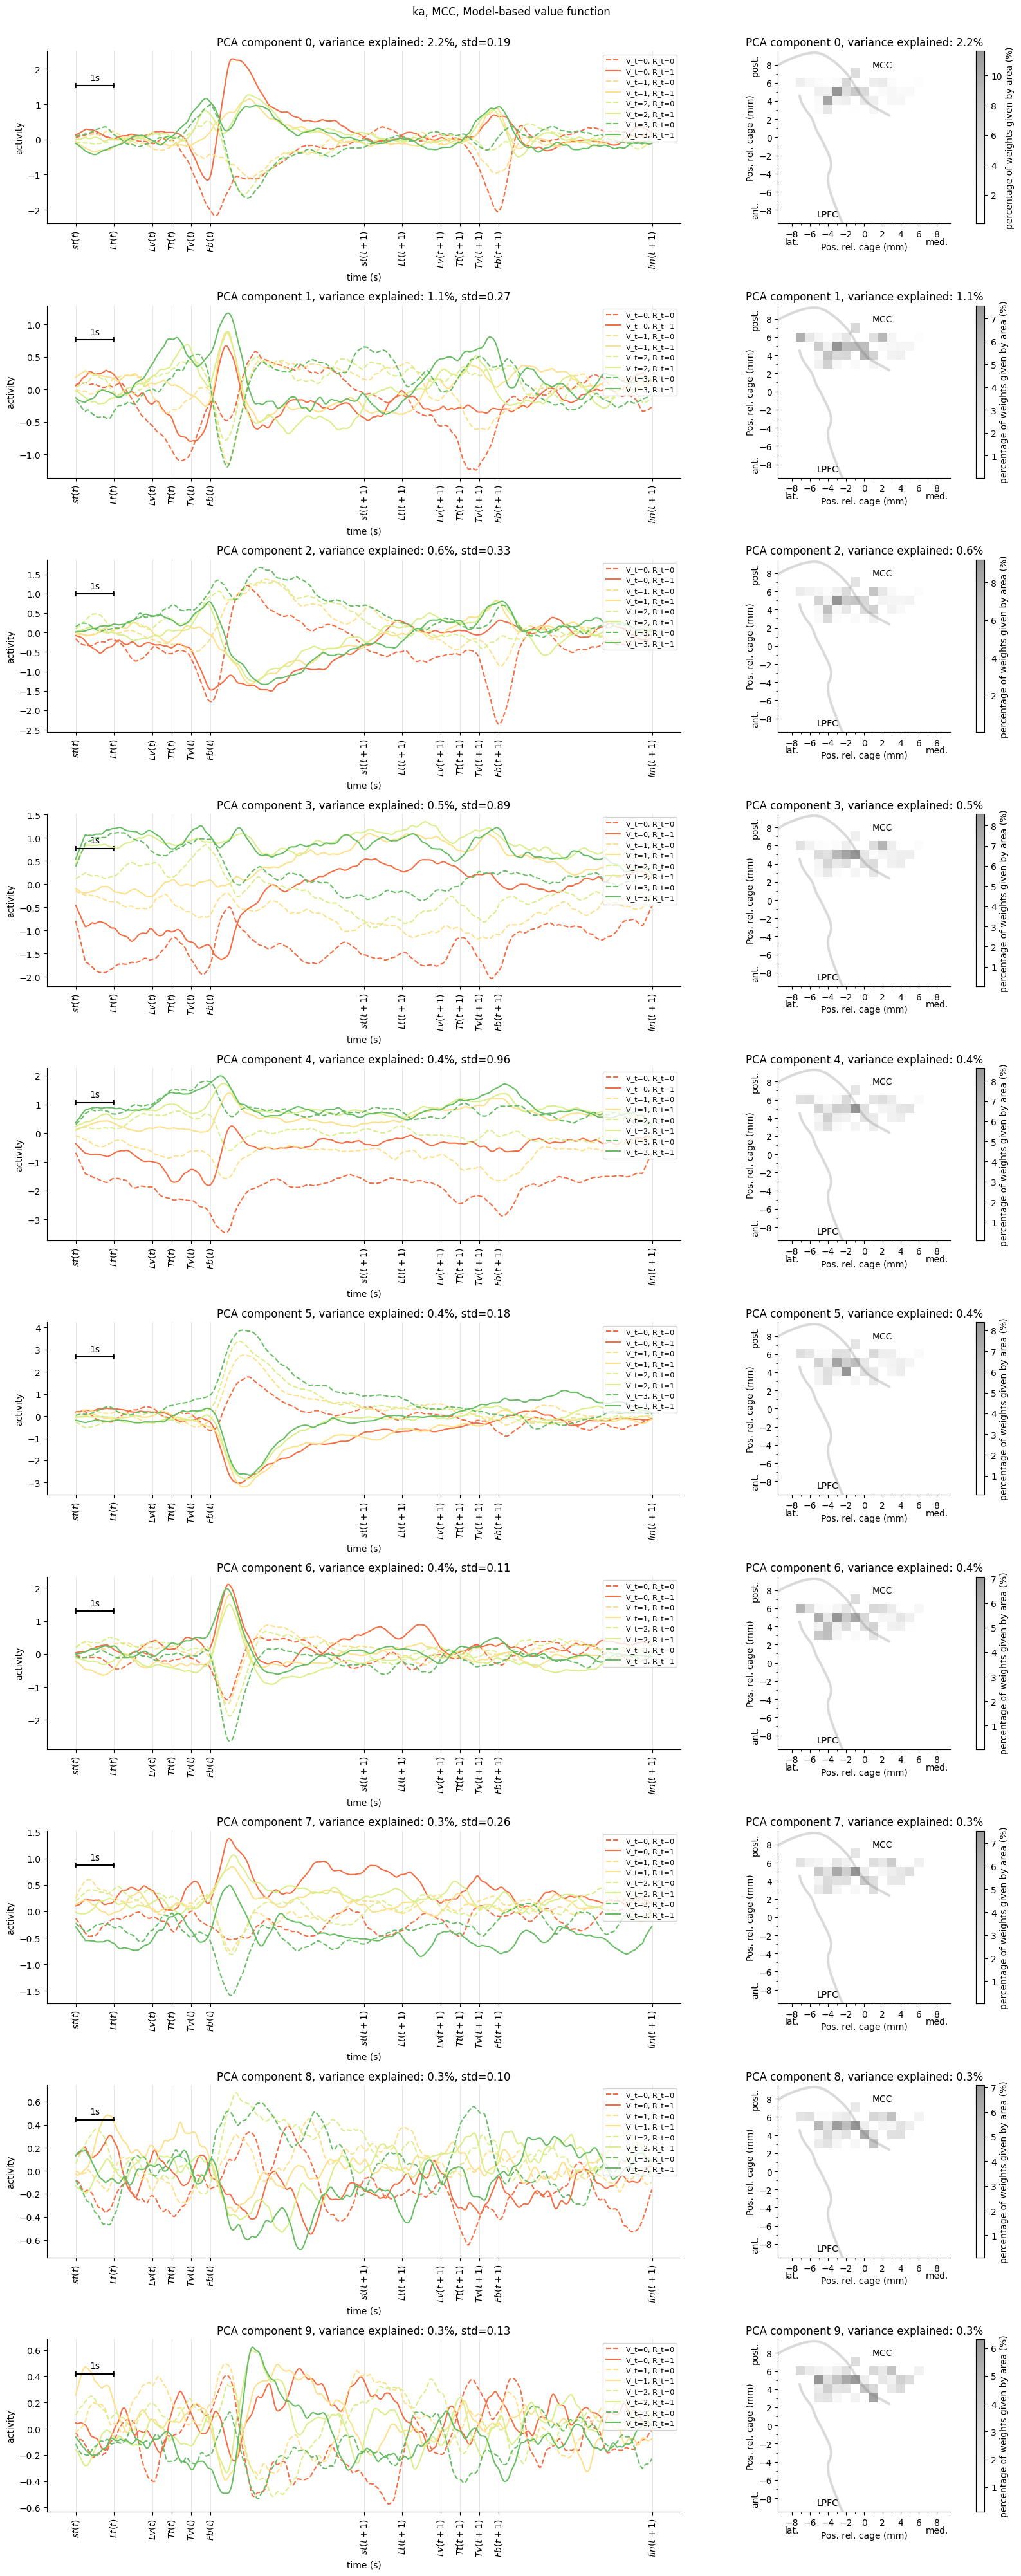

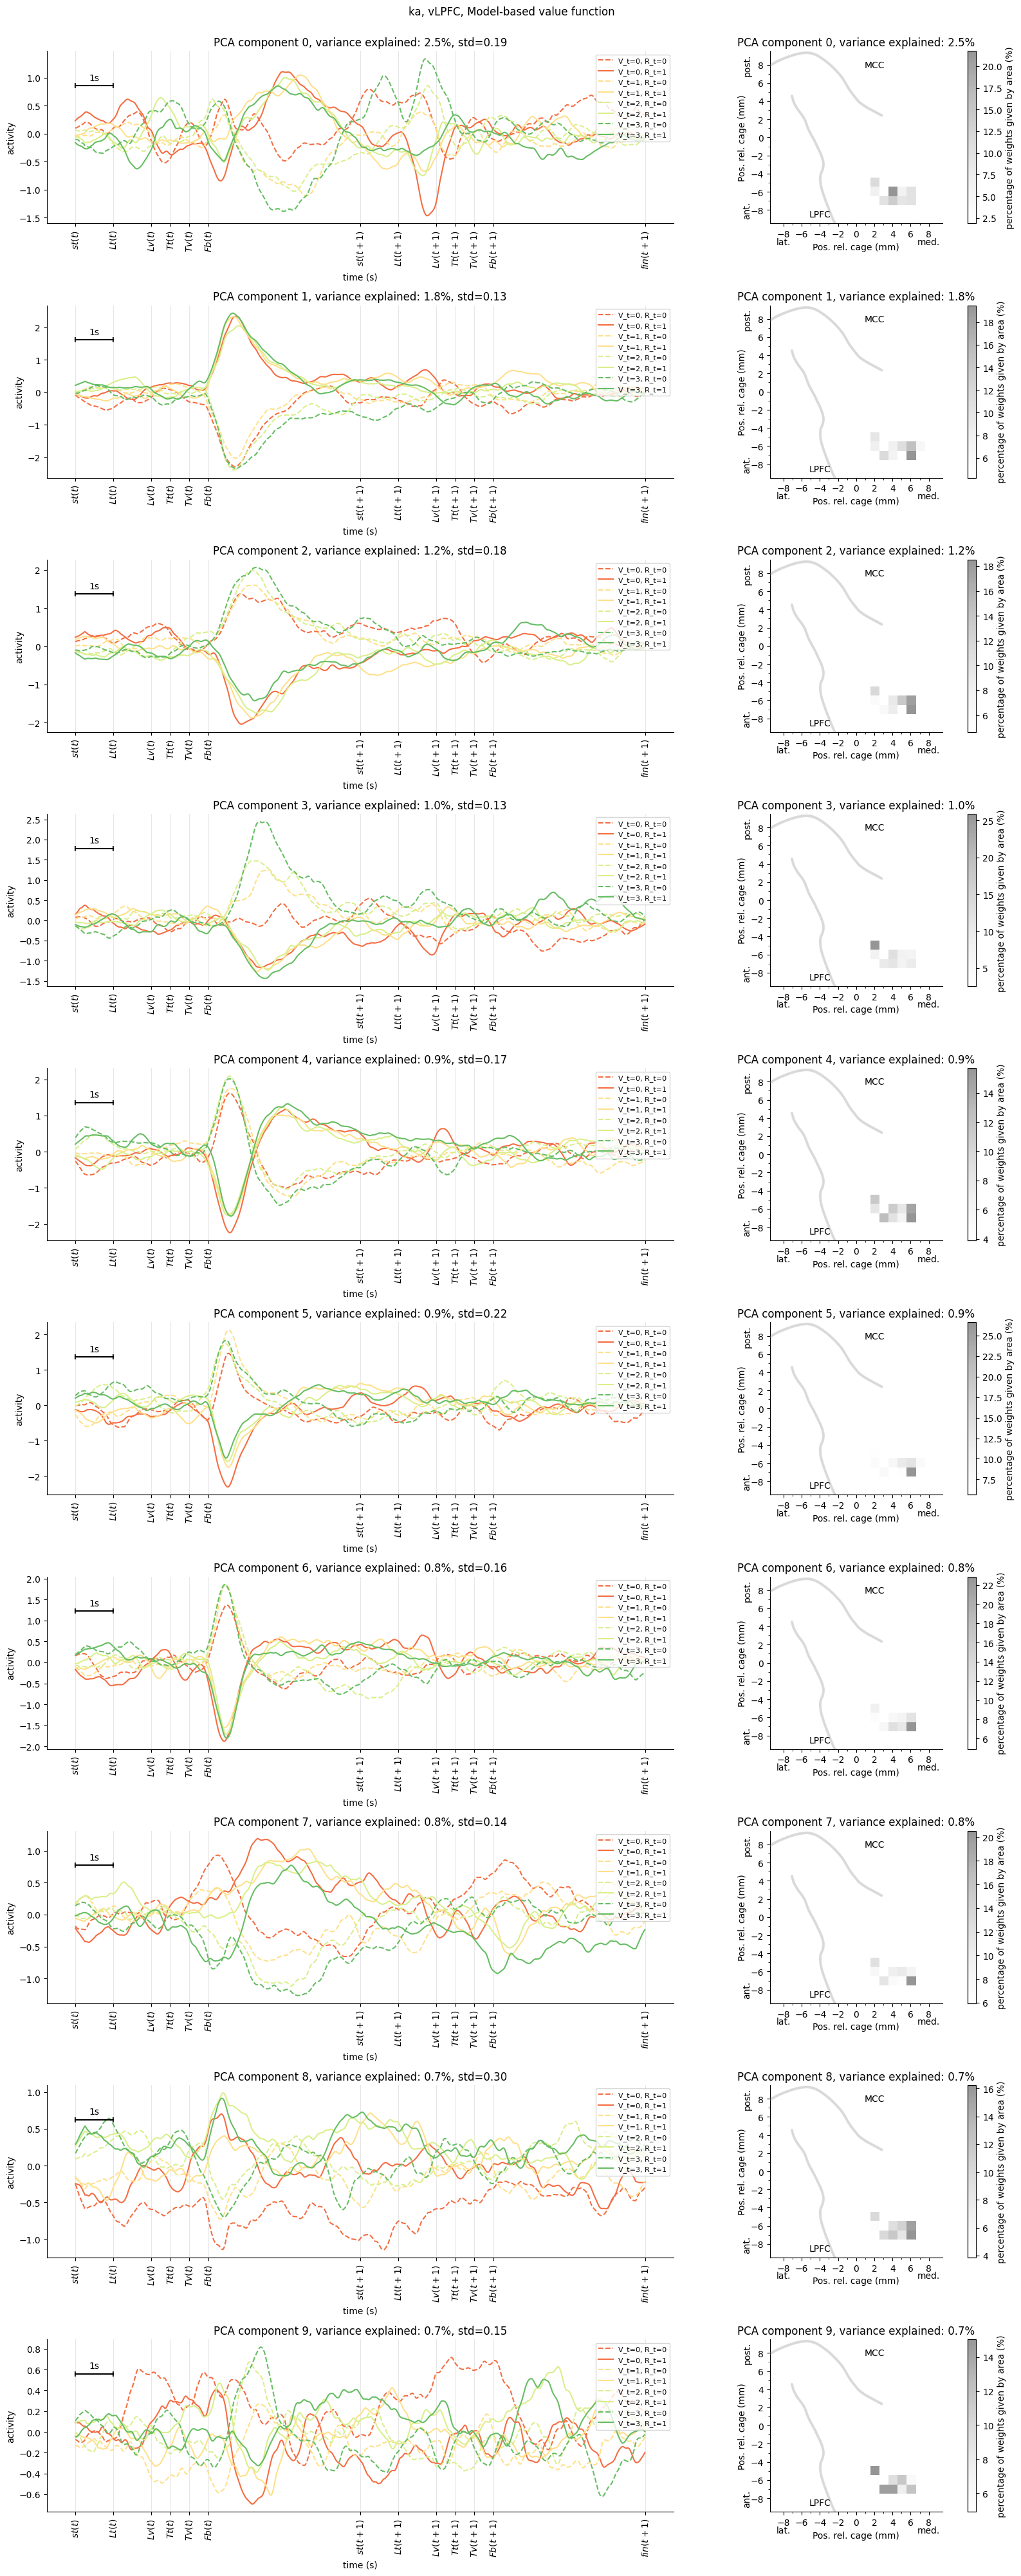

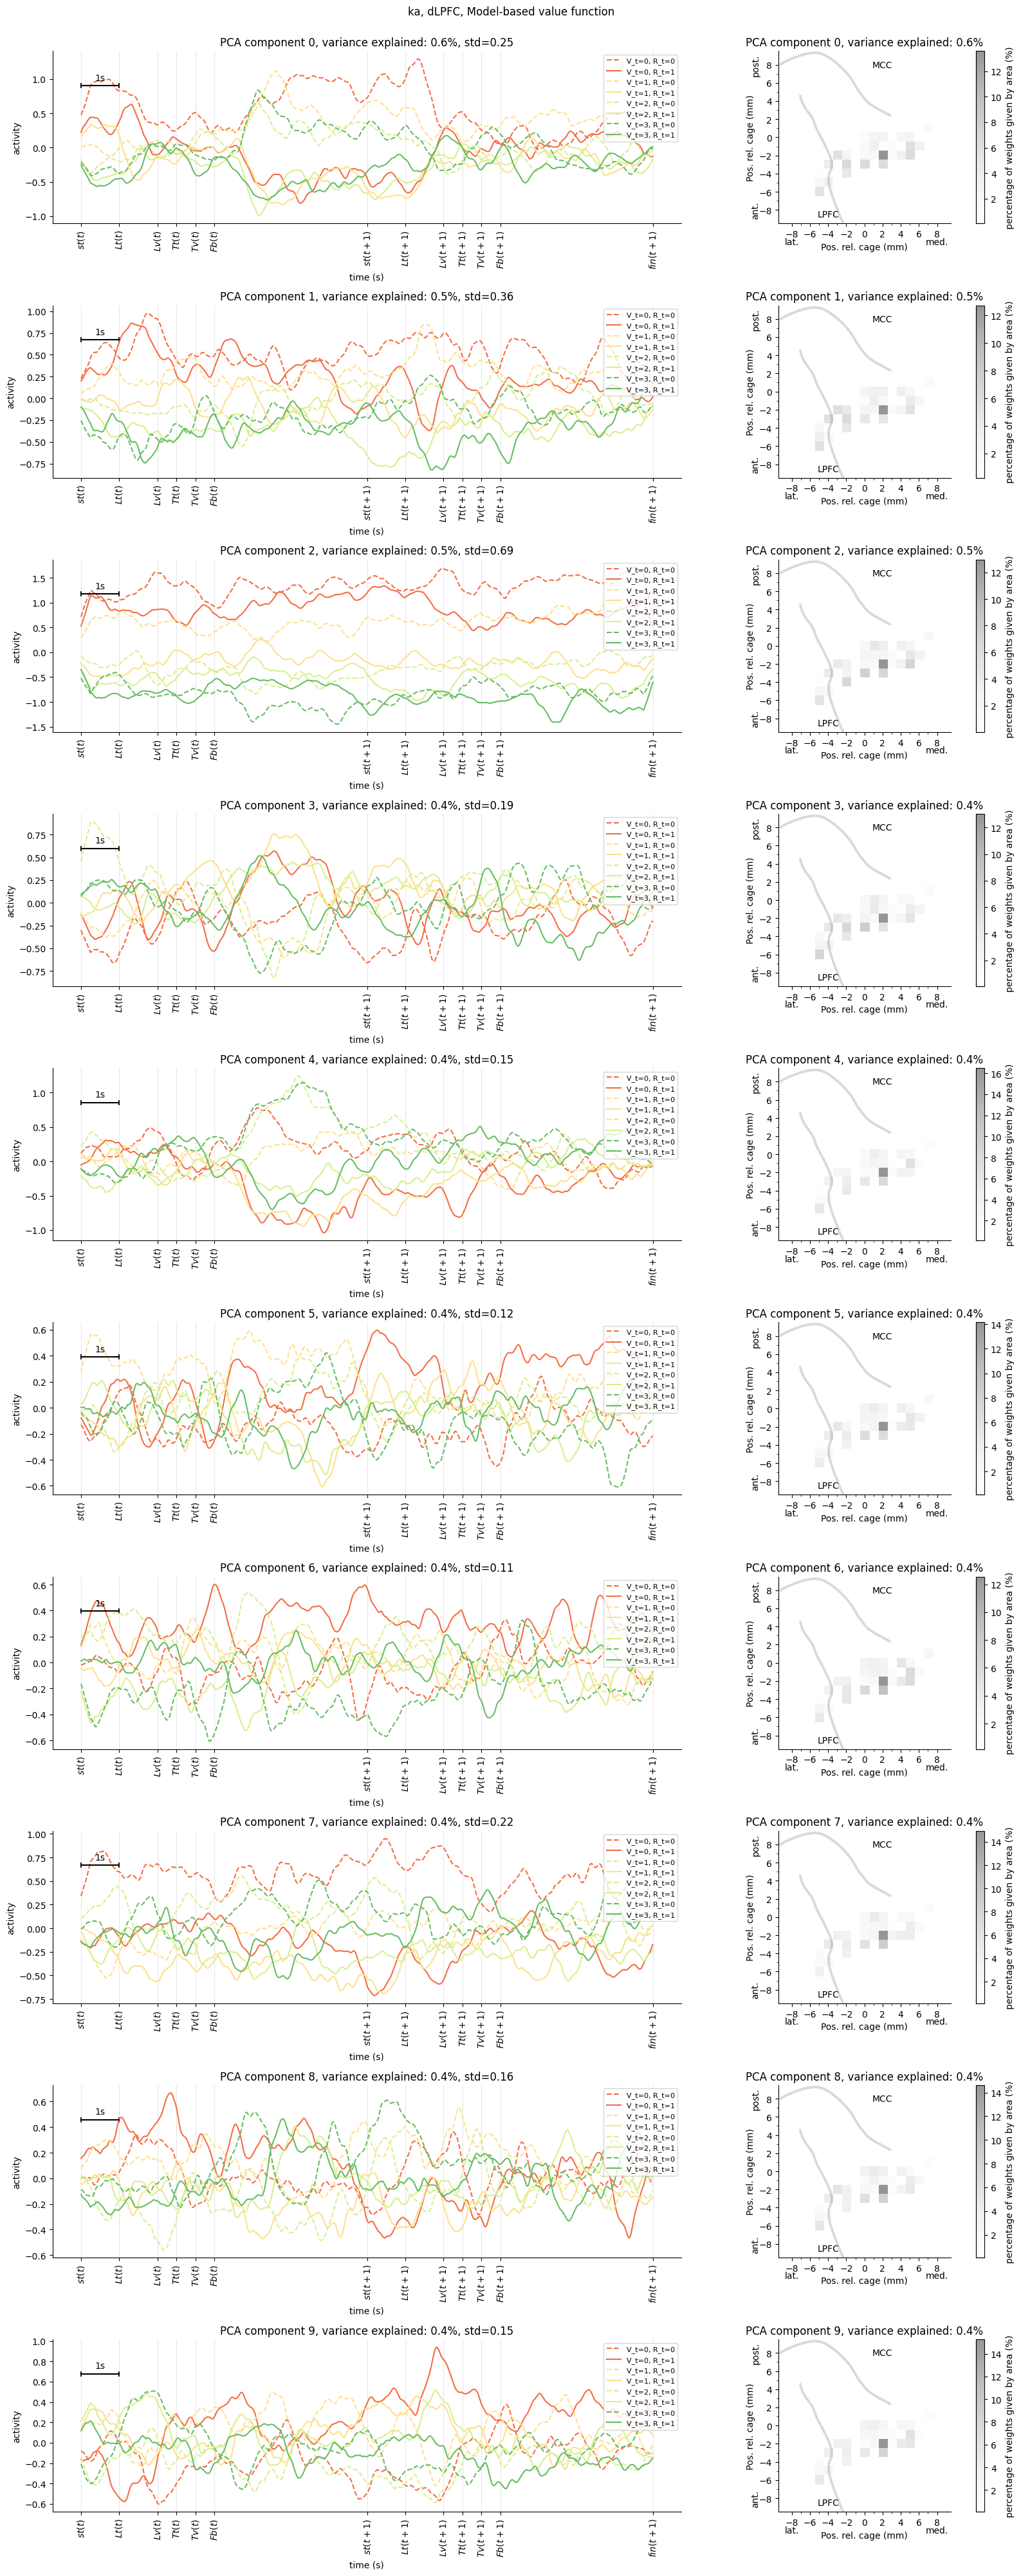

In [7]:
%matplotlib inline

for area in pca_dataset_all.keys():
    t_min, t_max = None, None  # 0, 11

    pca_dataset = pca_dataset_all[area]
    pca_components = pca_components_all[area]
    area_title = f'{area}, Model-based value function'

    fig, axs = plot_pca_components_value(pca_dataset, pca_components, monkey, area_title, n_components=10, t_min=t_min, t_max=t_max, mean_subtract=True)

    # save figure
    #fig.savefig(f'figs/pca_{monkey}_{area}.png', dpi=200, bbox_inches='tight')


# Check the value related variance per PC

Best PCs for area: MCC
Best PCs for area (mixed effect):
Top 10 significant neurons (sorted by R-squared):
Rank | Neuron Index | R-squared | p-value
---------------------------------------------
   1 |           3 |   1.0000 | 7.98e-47
   2 |           4 |   0.6875 | 6.96e-46
   3 |           2 |   0.1667 | 1.14e-13
   4 |          14 |   0.0428 | 2.87e-13
   5 |          74 |   0.0126 | 1.64e-03
   6 |          50 |   0.0112 | 4.23e-07
   7 |          80 |   0.0108 | 2.90e-05
   8 |          52 |   0.0099 | 6.73e-04
   9 |          21 |   0.0099 | 7.44e-04
  10 |          34 |   0.0094 | 3.95e-05
Best PCs for area: vLPFC
Best PCs for area (mixed effect):
Top 10 significant neurons (sorted by R-squared):
Rank | Neuron Index | R-squared | p-value
---------------------------------------------
   1 |           5 |   0.5929 | 4.15e-08
   2 |           8 |   0.2464 | 3.86e-08
   3 |          11 |   0.1996 | 3.42e-04
   4 |           2 |   0.1815 | 3.35e-04
   5 |          12 |   0.1015 | 1.

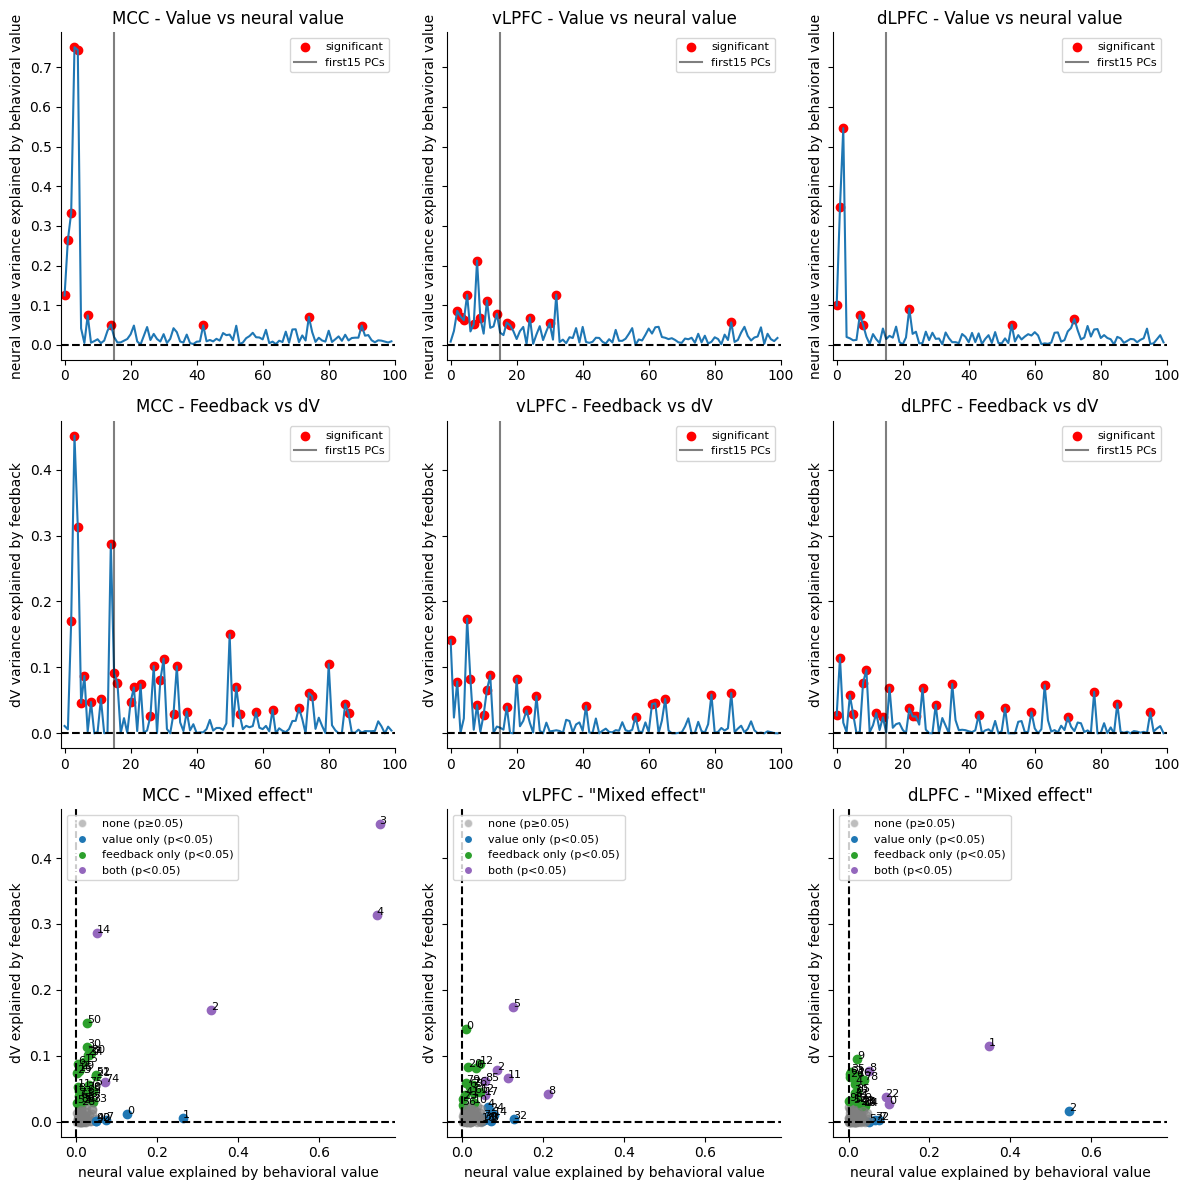

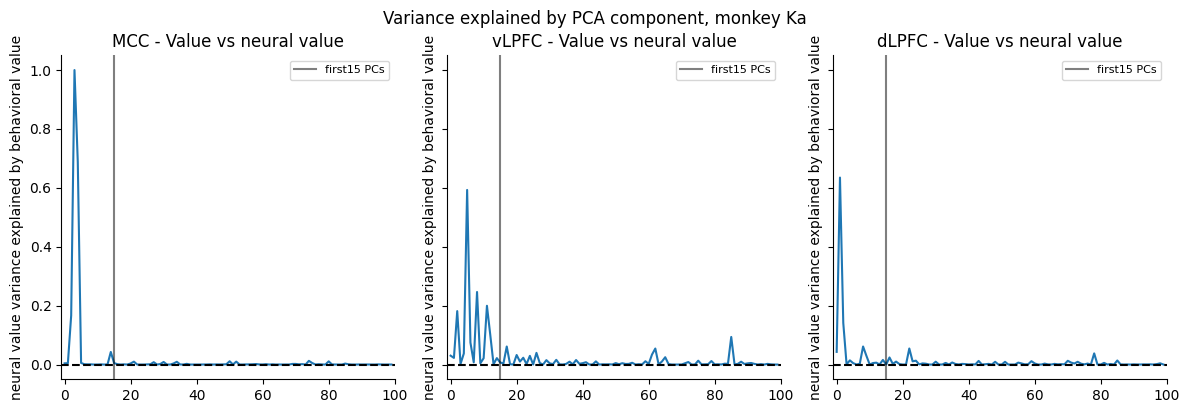

In [8]:
fig, axs = plot_explained_variance(pca_dataset_all, n_comps=100)
fig, axs = plot_mixed_explained_variance(pca_dataset_all, n_comps=100)
fig.suptitle(f'Variance explained by PCA component, monkey {monkey.capitalize()}', y=1.02)
plt.show()


In [9]:
def compute_explained_var(pca_dataset_all, n_comps=10000):
    res = {}
    for area, pca_dataset in pca_dataset_all.items():

        n_components = np.min((n_comps, len(pca_dataset.pca_component.values)))

        r2s_value, r2s_feedback = [], []
        pvals_value, pvals_feedback = [], []
        for i in range(n_components):  # loop through PCs and calculate variance
            # prepare data for this PC
            V_t = pca_dataset.firing_rates.sel(pca_component=i, time=slice(1, 3.5)).mean('time').data  # select PC, get one mean value per trial
            V_tp1 = pca_dataset.firing_rates.sel(pca_component=i, time=slice(8.5, 11)).mean('time').data  # select PC, get one mean value per trial
            dV = V_tp1 - V_t  # difference between timepoints

            behavioral_values = pca_dataset.value_function.values  # get behavioral values
            fbs = pca_dataset.feedback.values  # get feedback values

            # old way: just V_t agains behavioral values
            '''r_squared_value, pvalue_value = calculate_r_squared(V_t, behavioral_values)

            # new way: dV (continuous) against fbs (0, 1)
            r_squared_feedback, p_value_feedback = calculate_anova(dV, fbs)'''

            # new way 2: mixed effect model
            (r_squared_value, pvalue_value), (r_squared_feedback, p_value_feedback) = calculate_mixed_effect(behavioral_values, fbs, V_t, dV)

            r2s_value.append(r_squared_value)
            r2s_feedback.append(r_squared_feedback)
            pvals_value.append(pvalue_value)
            pvals_feedback.append(p_value_feedback)
        r2s_value = np.array(r2s_value)
        pvals_value = np.array(pvals_value)
        r2s_feedback = np.array(r2s_feedback)
        pvals_feedback = np.array(pvals_feedback)

        res[area] = {
            'r2s_value': r2s_value,
            'pvals_value': pvals_value,
            'r2s_feedback': r2s_feedback,
            'pvals_feedback': pvals_feedback,
        }
    return res

res = compute_explained_var(pca_dataset_all, n_comps=100)


# save res as pickle (add monkey name to filename)
import pickle
with open(f'results/pca_explained_var_{monkey}.pkl', 'wb') as f:
    pickle.dump(res, f)
# close file
f.close()



---
# Plot explained variance (both monkeys)

In [10]:
# load res for two monkeys and concatenate area-wise
import pickle
with open(f'results/pca_explained_var_ka.pkl', 'rb') as f:
    res_ka = pickle.load(f)
with open(f'results/pca_explained_var_po.pkl', 'rb') as f:
    res_po = pickle.load(f)

res_all = {'ka': {}, 'po': {}}
for area in res_ka.keys():
    res_all['ka'][area] = {
        'r2s_value': res_ka[area]['r2s_value'],
        'pvals_value': res_ka[area]['pvals_value'],
        'r2s_feedback': res_ka[area]['r2s_feedback'],
        'pvals_feedback': res_ka[area]['pvals_feedback']
    }
    res_all['po'][area] = {
        'r2s_value': res_po[area]['r2s_value'],
        'pvals_value': res_po[area]['pvals_value'],
        'r2s_feedback': res_po[area]['r2s_feedback'],
        'pvals_feedback': res_po[area]['pvals_feedback']
    }

res_all

{'ka': {'MCC': {'r2s_value': array([0.12478555, 0.26459937, 0.33287768, 0.75056557, 0.74352714,
          0.04152725, 0.00472817, 0.07440135, 0.00558104, 0.009421  ,
          0.0142073 , 0.0044554 , 0.01073503, 0.03545511, 0.0512115 ,
          0.0198076 , 0.00602866, 0.0062936 , 0.01054748, 0.01489791,
          0.02658738, 0.04866418, 0.00876866, 0.00076953, 0.02264721,
          0.04497073, 0.01223682, 0.02769323, 0.01478352, 0.00839349,
          0.02705584, 0.00480769, 0.01524785, 0.04203845, 0.03207299,
          0.00846265, 0.0059937 , 0.02592974, 0.00450024, 0.00213284,
          0.0079722 , 0.00890916, 0.04910849, 0.00902068, 0.01233747,
          0.00878214, 0.01529455, 0.01073949, 0.02983925, 0.0245108 ,
          0.02597164, 0.01195401, 0.04827233, 0.0021705 , 0.0058536 ,
          0.01688575, 0.02209566, 0.03046549, 0.01922597, 0.01866283,
          0.0138831 , 0.03796123, 0.00442837, 0.00824095, 0.00182056,
          0.01052247, 0.0071838 , 0.03334417, 0.00549628, 0.0388

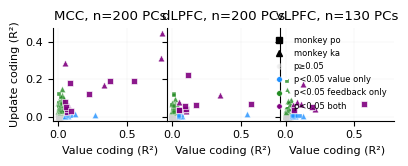

In [11]:
def plot_explained_variance(res_all, n_comps=10000, paperformat=False):
    
    if paperformat:
        plt.rcParams.update({'font.size': 8})
        lw = 1
        s_s, s_t = 13*1.2, 20*1.2
        h, w = 2.5*.85 * .8, 6*.85 * .8
    else:   
        plt.rcParams.update({'font.size': 18})
        lw = 3
        s = 40
        h, w = 4, 12

    # no gap between subplots
    fig, axs = plt.subplots(1, 3, figsize=(w, h), sharex=True, sharey=True, gridspec_kw={'wspace': 0})

    # rectangle and triangle markers for monkeys
    markers = {'po': 's', 'ka': '^'}
    sizes = {'po': s_s, 'ka': s_t}

    for ax_i, area in enumerate(['MCC', 'dLPFC', 'vLPFC']):

        n_comps_all = 0
        for monkey in ['ka', 'po']:
            res = res_all[monkey]
            n_components = np.min((n_comps, len(res[area]['r2s_value'])))
            n_comps_all += n_components

            r2s_value = res[area]['r2s_value'][:n_components]
            pvals_value = res[area]['pvals_value'][:n_components]
            r2s_feedback = res[area]['r2s_feedback'][:n_components]
            pvals_feedback = res[area]['pvals_feedback'][:n_components]

            # Get current axis
            ax = axs[ax_i]
            
            # Separate points by significance pattern
            both_sig = (pvals_value < 0.05) & (pvals_feedback < 0.05)
            value_only = (pvals_value < 0.05) & (pvals_feedback >= 0.05)
            feedback_only = (pvals_value >= 0.05) & (pvals_feedback < 0.05)
            neither_sig = (pvals_value >= 0.05) & (pvals_feedback >= 0.05)
            
            # Plot points with clear visual hierarchy (no numbers!)
            if np.any(neither_sig):
                ax.scatter(r2s_value[neither_sig], r2s_feedback[neither_sig], 
                        c='lightgrey', alpha=0.4, s=sizes[monkey]*0.6, zorder=1, marker=markers[monkey])

            if np.any(value_only):
                ax.scatter(r2s_value[value_only], r2s_feedback[value_only], 
                        c='dodgerblue', alpha=0.8, s=sizes[monkey]*0.8, zorder=2, 
                        edgecolors='white', linewidths=lw*0.3, marker=markers[monkey])

            if np.any(feedback_only):
                ax.scatter(r2s_value[feedback_only], r2s_feedback[feedback_only], 
                        c='forestgreen', alpha=0.8, s=sizes[monkey]*0.8, zorder=2, 
                        edgecolors='white', linewidths=lw*0.3, marker=markers[monkey])

            if np.any(both_sig):
                ax.scatter(r2s_value[both_sig], r2s_feedback[both_sig], 
                        c='purple', alpha=0.9, s=sizes[monkey], zorder=3, 
                        edgecolors='white', linewidths=lw*0.5, marker=markers[monkey])

            # Add diagonal reference line
            #max_val_value = np.max(r2s_value) * 1.1
            #max_val_feedback = np.max(r2s_feedback) * 1.1
            #max_value = max(max_val_value, max_val_feedback)

            '''ax.plot([0, 1], [0, 1], '--', color='darkgrey', 
                    alpha=0.6, linewidth=lw*0.8, zorder=0, label='Unity line')'''
            
        # Clean styling
        ax.set_xlabel('Value coding (R²)')
        ax.set_title(f'{area}, n={n_comps_all} PCs')
        
        # Set clean axis limits
        '''ax.set_xlim(-0.005, max_val_value)
        ax.set_ylim(-0.005, max_val_feedback)'''

        # Minimal grid
        ax.grid(True, alpha=0.2, linewidth=lw*0.3)
        
        # Clean spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.spines['left'].set_linewidth(lw*0.5)
        #ax.spines['bottom'].set_linewidth(lw*0.5)
        #ax.tick_params(width=lw*0.5, length=lw*2)

    # Legend only on first subplot
    legend_elements = [
       plt.Line2D([0], [0], marker='s', color='w', label='monkey po', markerfacecolor='k', markersize=4, markeredgecolor='k', markeredgewidth=1),
       plt.Line2D([0], [0], marker='^', color='w', label='monkey ka', markerfacecolor='k', markersize=4, markeredgecolor='k', markeredgewidth=1),
       plt.Line2D([0], [0], marker='o', color='w', label='p≥0.05', markerfacecolor='lightgrey', markersize=4, alpha=0.4),
       plt.Line2D([0], [0], marker='o', color='w', label='p<0.05 value only', markerfacecolor='dodgerblue', markersize=4, markeredgecolor='white', markeredgewidth=lw*0.3),
       plt.Line2D([0], [0], marker='o', color='w', label='p<0.05 feedback only', markerfacecolor='forestgreen', markersize=4, markeredgecolor='white', markeredgewidth=lw*0.3),
       plt.Line2D([0], [0], marker='o', color='w', label='p<0.05 both', markerfacecolor='purple', markersize=4, markeredgecolor='white', markeredgewidth=lw*0.5),
    ]
    
    axs[0].set_ylabel('Update coding (R²)')

    axs[2].legend(handles=legend_elements, loc='upper right', 
                  frameon=False, fancybox=False, shadow=False, 
                  fontsize=plt.rcParams['font.size']*0.75)
    
    plt.tight_layout()
    return fig, axs

fig, axs = plot_explained_variance(res_all, n_comps=2000, paperformat=True)
fig.savefig(f'figs/pca_explained_variance_both.svg', dpi=300, bbox_inches='tight', transparent=True)

In [12]:
pca_dataset_MCC.sel(pca_component=3)

<xarray.Dataset>
Dimensions:         (time: 1500, trial_id: 160)
Coordinates:
    subregion       object MCC
  * time            (time) float64 0.0 0.01 0.02 0.03 ... 14.97 14.98 14.99
    epoch           (time) float64 ...
    feedback        (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1
    stay_value      (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3
  * trial_id        (trial_id) int64 0 1 2 3 4 5 6 ... 154 155 156 157 158 159
    value_function  (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3
    pca_component   int64 3
    explained_var   float64 0.004754
Data variables:
    firing_rates    (trial_id, time) float64 -1.731 -1.934 ... 0.1728 0.101
Attributes:
    bin_size:  0.01

---
# Multi-dimensional PCA plots

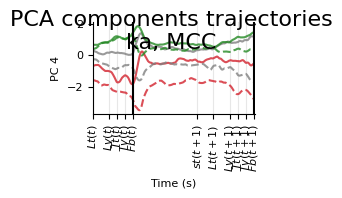

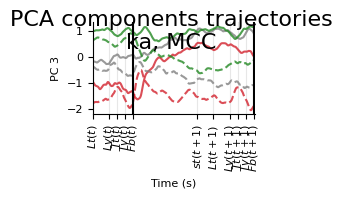

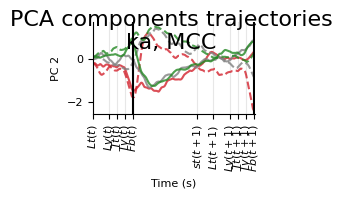

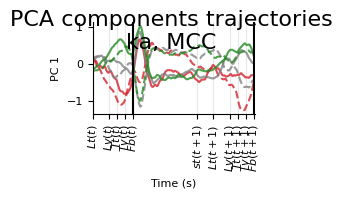

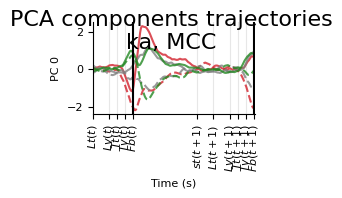

In [13]:
# plot setting: normal, not 3d or interactive
%matplotlib inline

pca_comps = {'ka': [4, 3, 2, 1, 0], 'po': [5, 0, 6, 2, 8]}  # 5 for PO, 3 for KA

# Plot PCA trajectory for each area
for pca_comp_temp in pca_comps[monkey]:
    fig, ax = plot_pca_trajectory(pca_dataset_MCC, monkey, pca_comp_temp, paper_format=True)
    fig.suptitle(f'PCA components trajectories\n{monkey}, MCC', fontsize=16)

    # remove legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()

    # Export 3d plot in interactive mode
    # save to svg
    fig.savefig(f'figs/pca_trajectory_{monkey}_MCC_pc{pca_comp_temp}.svg', dpi=300, bbox_inches='tight', transparent=True)

    #plt.close(fig)

    # plot switch_proba (x axis) vs pca activity (y axis) for each pca_comp_temp
    """fig, ax = plt.subplots(figsize=(1.5, 2.2))
    switch_proba = neural_dataset_MCC.switch_proba.values
    pca_activity = pca_dataset_MCC.firing_rates.sel(pca_component=pca_comp_temp, time=slice(3.5, 9)).mean('time').values
    labels = pca_dataset_MCC.value_function.values
    colors = [COLORS[0], 'grey', 'lightgrey', COLORS[1]]
    labels_2 = pca_dataset_MCC.feedback.values
    markers = {1:'o', 0:'x'}
    for label in np.unique(labels):
        for label_2 in np.unique(labels_2):
            mask = (labels == label) & (labels_2 == label_2)
            ax.scatter(switch_proba[mask], pca_activity[mask], 
                      alpha=0.5, c=colors[label], s=10, marker=markers[label_2],
                      label=f'V={label}, R={label_2}' if label in [0, 3] else "")

    ax.set_xlabel('Probability of switch')
    ax.set_ylabel(f'PC {pca_comp_temp} activity')
    #ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{monkey}, MCC, PC{pca_comp_temp}')
    sns.despine()"""
    #fig.savefig(f'figs/pca_proba_switch_{monkey}_MCC_pc{pca_comp_temp}.svg', dpi=300, bbox_inches='tight', transparent=True)


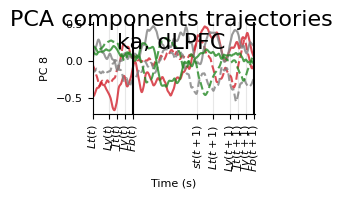

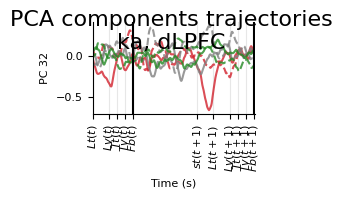

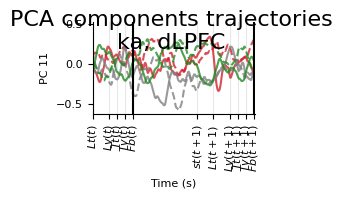

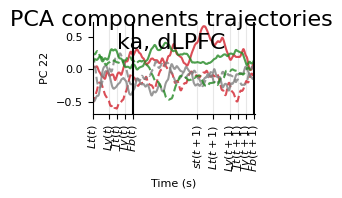

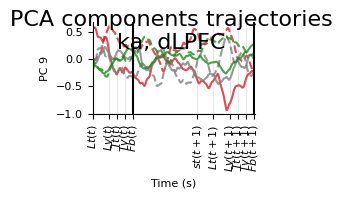

In [14]:
pca_comps = {'ka': [8, 32, 11, 22, 9], 'po': [2, 4, 1, 5, 3]}  # 5 for PO, 3 for KA

# Plot PCA trajectory for each area
for pca_comp_temp in pca_comps[monkey]:
    fig, ax = plot_pca_trajectory(pca_dataset_dLPFC, monkey, pca_comp_temp, paper_format=True)
    fig.suptitle(f'PCA components trajectories\n{monkey}, dLPFC', fontsize=16)

    # remove legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()

    # Export 3d plot in interactive mode
    # save to svg
    plt.savefig(f'figs/pca_trajectory_{monkey}_dLPFC_pc{pca_comp_temp}.svg', dpi=200, bbox_inches='tight', transparent=True)

    #plt.close(fig)


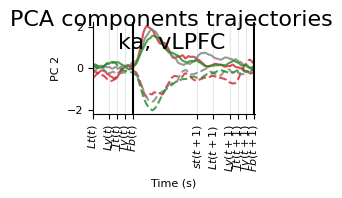

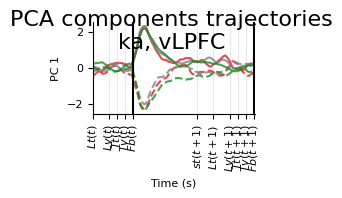

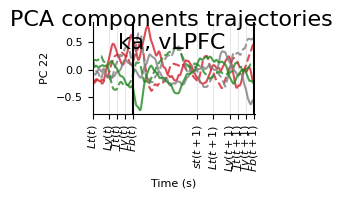

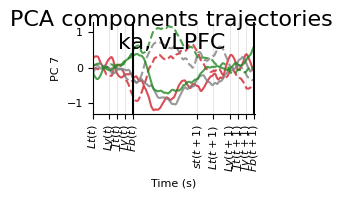

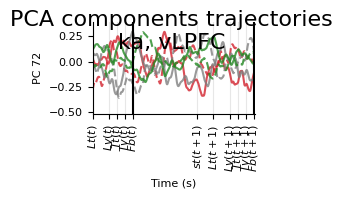

In [15]:
pca_comps = {'ka': [2, 1, 22, 7, 72], 'po': [0, 6, 10, 19, 26]}  # 5 for PO, 3 for KA

# Plot PCA trajectory for each area
for pca_comp_temp in pca_comps[monkey]:
    fig, ax = plot_pca_trajectory(pca_dataset_vLPFC, monkey, pca_comp_temp, paper_format=True)
    fig.suptitle(f'PCA components trajectories\n{monkey}, vLPFC', fontsize=16)

    # remove legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()

    # Export 3d plot in interactive mode
    # save to svg
    plt.savefig(f'figs/pca_trajectory_{monkey}_vLPFC_pc{pca_comp_temp}.svg', dpi=200, bbox_inches='tight', transparent=True)

    #plt.close(fig)


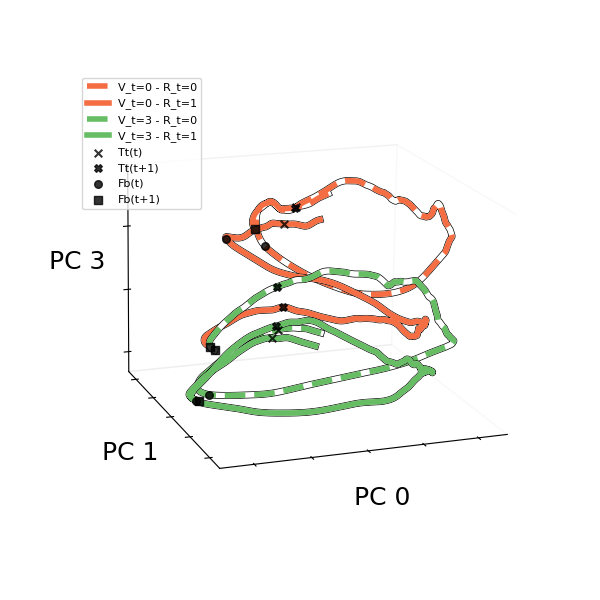

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
%matplotlib widget

pc1s = {'ka': [0, 1, 3], 'po': [0, 2, 5]}

fig, ax = plot_3d_pca_trajectory(pca_dataset_MCC, pc1=pc1s[monkey][0], pc2=pc1s[monkey][1], pc3=pc1s[monkey][2])

# sve svg
#plt.savefig(f'figs/pca_trajectory_loop.svg', dpi=200, bbox_inches='tight', transparent=True)
plt.show()
